In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, mannwhitneyu
import folium
from folium.plugins import HeatMap

In [2]:
gdf = gpd.read_file('../data/cleaned/Collision_All_Filtered.geojson')
gdf = gdf.to_crs(epsg=4326)
gdf['X'] = gdf.geometry.x
gdf['Y'] = gdf.geometry.y
gdf.dropna(subset=['X', 'Y'], inplace=True)
gdf

,OBJECTID,SE_ANNO_CAD_DATA,INCKEY,COLDETKEY,REPORTNO,STATUS,ADDRTYPE,INTKEY,LOCATION,EXCEPTRSNCODE,...,LIGHTCOND_RAW,JUNCTIONTYPE_RAW,UNDERINFL_RAW,Day_of_Week,Season,GEOMETRY_STATUS,HAS_VALID_GEOMETRY,geometry,X,Y
0,1,,384696,386236,EF67714,Matched,I,26782.0,IRONDALE AVE W AND W BERTONA ST,None,...,Daylight,At Intersection (intersection related),N,Wednesday,Winter,valid,True,POINT (-122.36555 47.65046),-122.365545,47.650458
1,2,,382571,384091,3931753,Matched,B,NaN,1ST AVE S BETWEEN S FIDALGO ST AND EAST MARGIN...,None,...,Daylight,Mid-Block (not related to intersection),N,Monday,Spring,valid,True,POINT (-122.33421 47.54938),-122.334212,47.549380
2,3,,382297,383817,EF97031,Unmatched,B,NaN,47TH AVE NE BETWEEN NE 70TH W ST AND NE 71ST ST,None,...,None,Mid-Block (not related to intersection),None,Friday,Spring,valid,True,POINT (-122.27848 47.67972),-122.278475,47.679724
3,4,,382328,383848,EF97000,Matched,I,30509.0,4TH AVE S AND S JACKSON ST,None,...,Daylight,At Intersection (intersection related),N,Friday,Spring,valid,True,POINT (-122.32897 47.5992),-122.328968,47.599197
4,5,,382682,384202,EF99053,Unmatched,B,NaN,BEACON ER AVE S BETWEEN S EDDY ST AND S MORGAN ST,None,...,None,Mid-Block (not related to intersection),None,Monday,Summer,valid,True,POINT (-122.29992 47.54501),-122.299918,47.545014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109035,261877,,387345,388885,EG46574,Unmatched,B,NaN,E HARRISON ST BETWEEN 15TH N AVE E AND 16TH AVE E,None,...,None,Mid-Block (not related to intersection),None,Thursday,Fall,valid,True,POINT (-122.312 47.62208),-122.312000,47.622085
109036,261878,,389104,390644,EG60031,Matched,I,33046.0,1ST AVE S AND EAST MARGINAL WAY S,None,...,Daylight,At Intersection (intersection related),N,Tuesday,Winter,valid,True,POINT (-122.33431 47.54827),-122.334309,47.548271
109037,261879,,387459,388999,3924867,Matched,I,29622.0,1ST AVE AND MARION ST,None,...,Dark - Street Lights On,At Intersection (intersection related),N,Friday,Winter,valid,True,POINT (-122.33559 47.60398),-122.335586,47.603982
109038,261880,,387840,389380,EG45297,Matched,I,29801.0,BROADWAY AND JAMES ST,None,...,Daylight,At Intersection (intersection related),N,Tuesday,Fall,valid,True,POINT (-122.32075 47.60722),-122.320752,47.607218


In [3]:
# Overall collision density heatmap
gradient = {
    0.2: 'blue',
    0.4: 'lime',
    0.6: 'yellow',
    0.8: 'orange',
    1.0: 'red'
}
sf_map = folium.Map(location=[gdf['Y'].mean(), gdf['X'].mean()],  zoom_start=12, control_scale=True, min_zoom=11)
HeatMap(data=gdf[["X","Y","VEHCOUNT"]].groupby(['Y', 'X']).sum().reset_index().values.tolist(), radius=8, max_zoom=13, gradient=gradient).add_to(sf_map)

display(sf_map)

In [4]:
gdf = gdf.dropna(subset=['geometry'])
gdf['SEVERITY'] = gdf['INJURIES'] + (gdf['SERIOUSINJURIES'] * 3) + (gdf['FATALITIES'] * 5)
df_pre = gdf[gdf['YEAR'] < 2020]
df_post = gdf[gdf['YEAR'] >= 2020]

pre_2020 = df_pre['SEVERITY']   
post_2020 = df_post['SEVERITY']

print(f'{pre_2020.describe()}\n')
print(f'{post_2020.describe()}\n')

print(f'Pre-2020 mean severity per collision: {pre_2020.mean():.2f}')
print(f'Post-2020 mean severity per collision: {post_2020.mean():.2f}')

U1, p = mannwhitneyu(pre_2020, post_2020, alternative='two-sided')
print(f'\nMann-Whitney U statistic: {U1:.2f}, p-value: {p:.4f}')

count    61822.000000
mean         0.362250
std          0.799868
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         20.000000
Name: SEVERITY, dtype: float64

count    44228.000000
mean         0.485530
std          1.030322
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         16.000000
Name: SEVERITY, dtype: float64

Pre-2020 mean severity per collision: 0.36
Post-2020 mean severity per collision: 0.49

Mann-Whitney U statistic: 1293080977.00, p-value: 0.0000


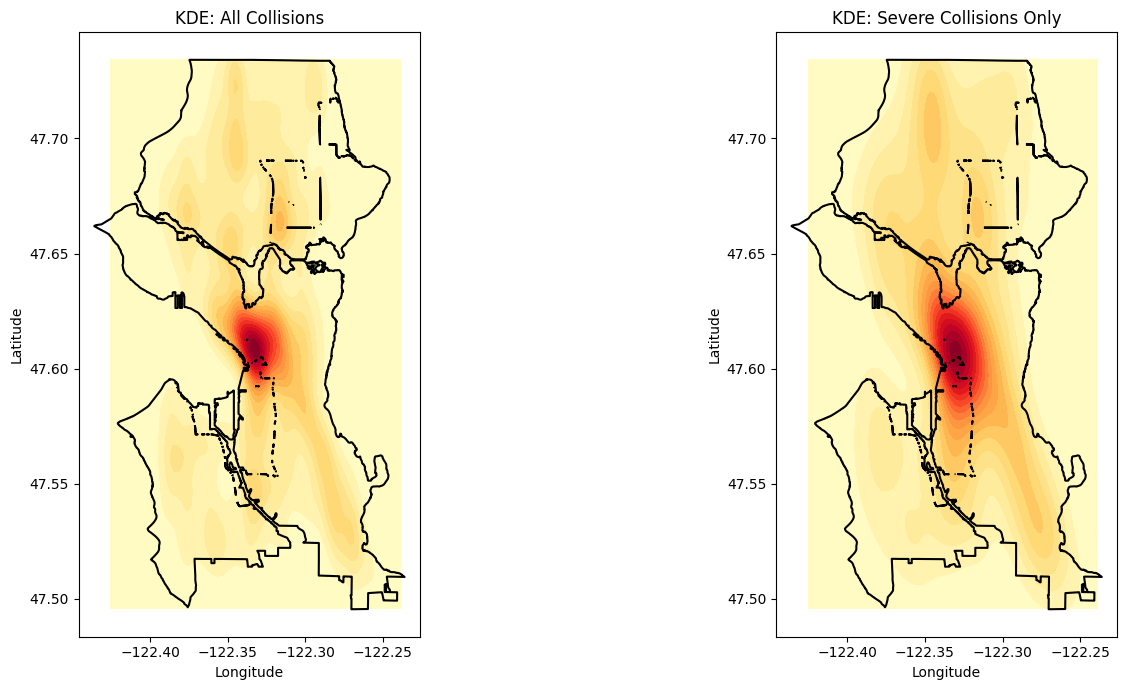

In [5]:
# Dissolve Seattle neighborhood polygons into a single Seattle city outline
seattle_boundary = (
    gpd.read_file('../data/processed/Neighborhood_Map_Atlas_Neighborhoods.geojson')
    .to_crs(gdf.crs)
    .dissolve()
)

coords_all = np.vstack([gdf.geometry.x, gdf.geometry.y])

df_severe = gdf[(gdf['FATALITIES'] > 0) | (gdf['SERIOUSINJURIES'] > 0)]
coords_severe = np.vstack([df_severe.geometry.x, df_severe.geometry.y])

kde_all = gaussian_kde(coords_all)
kde_severe = gaussian_kde(coords_severe)

# Contour (hotspot) map of collision severity
x = np.linspace(gdf['X'].min(), gdf['X'].max(), 150)
y = np.linspace(gdf['Y'].min(), gdf['Y'].max(), 150)
xx, yy = np.meshgrid(x, y)
grid_points = np.vstack([xx.ravel(), yy.ravel()])

z_all = kde_all(grid_points).reshape(xx.shape)
z_severe = kde_severe(grid_points).reshape(xx.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 7))
ax[0].contourf(xx, yy, z_all, cmap='YlOrRd', levels=20)
ax[0].set_title('KDE: All Collisions')
ax[1].contourf(xx, yy, z_severe, cmap='YlOrRd', levels=20)
ax[1].set_title('KDE: Severe Collisions Only')

for axis in ax:
    seattle_boundary.boundary.plot(
        ax=axis, color='black', linewidth=1.5, zorder=3
    )
    axis.set_xlabel('Longitude')
    axis.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

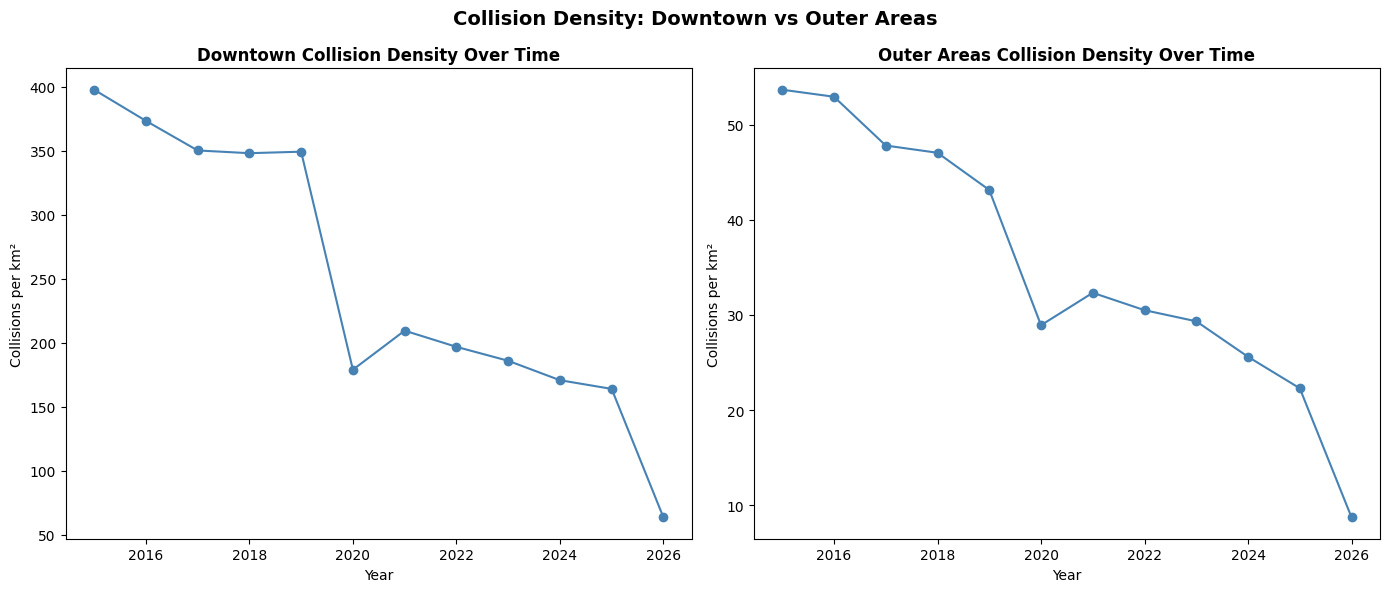

Collision Density Change Post-2020:
Downtown:
  Pre-2020 avg density:  363.82
  2020 Onwards avg density: 167.09
  % Change: -54.1%
Outer:
  Pre-2020 avg density:  48.91
  2020 Onwards avg density: 25.38
  % Change: -48.1%


In [6]:
# Assign each collision to a Seattle neighborhood polygon
neighborhoods = (
    gpd.read_file('../data/processed/Neighborhood_Map_Atlas_Neighborhoods.geojson')
    .to_crs(gdf.crs)
)

collisions_by_neighborhood = gpd.sjoin(
    gdf,
    neighborhoods[['L_HOOD', 'S_HOOD', 'geometry']],
    how='left',
    predicate='within',
)

in_seattle = collisions_by_neighborhood['L_HOOD'].notna()
downtown_mask = collisions_by_neighborhood['L_HOOD'].eq('Downtown')
df_downtown = collisions_by_neighborhood.loc[downtown_mask].copy()
df_outer = collisions_by_neighborhood.loc[in_seattle & ~downtown_mask].copy()

# Count collisions per zone per year
downtown_by_year = df_downtown.groupby('YEAR').size().reset_index(name='COUNT')
outer_by_year = df_outer.groupby('YEAR').size().reset_index(name='COUNT')

# Calculate true polygon areas in square kilometers
area_crs = neighborhoods.estimate_utm_crs()
neighborhoods_projected = neighborhoods.to_crs(area_crs)
downtown_projected = neighborhoods_projected[
    neighborhoods_projected['L_HOOD'].eq('Downtown')
]

seattle_area_km2 = neighborhoods_projected.dissolve().geometry.area.iloc[0] / 1e6
downtown_area_km2 = downtown_projected.dissolve().geometry.area.iloc[0] / 1e6
outer_area_km2 = seattle_area_km2 - downtown_area_km2

downtown_by_year['DENSITY'] = downtown_by_year['COUNT'] / downtown_area_km2
outer_by_year['DENSITY'] = outer_by_year['COUNT'] / outer_area_km2

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (label, data) in zip(axes, [('Downtown', downtown_by_year), 
                                      ('Outer Areas', outer_by_year)]):
    ax.plot(data['YEAR'], data['DENSITY'], marker='o', color='steelblue')
    ax.set_title(f'{label} Collision Density Over Time', fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Collisions per km²')

plt.suptitle('Collision Density: Downtown vs Outer Areas', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summarize pre/post change
print("Collision Density Change Post-2020:")
for label, data in [('Downtown', downtown_by_year), ('Outer', outer_by_year)]:
    pre = data[data['YEAR'] < 2020]['DENSITY'].mean()
    post = data[data['YEAR'] >= 2020]['DENSITY'].mean()
    pct_change = ((post - pre) / pre) * 100
    print(f"{label}:")
    print(f"  Pre-2020 avg density:  {pre:.2f}")
    print(f"  2020 Onwards avg density: {post:.2f}")
    print(f"  % Change: {pct_change:+.1f}%")

/var/folders/kg/syn5dsfn40l0n2qfhr_8whqh0000gn/T/ipykernel_67862/2191128830.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


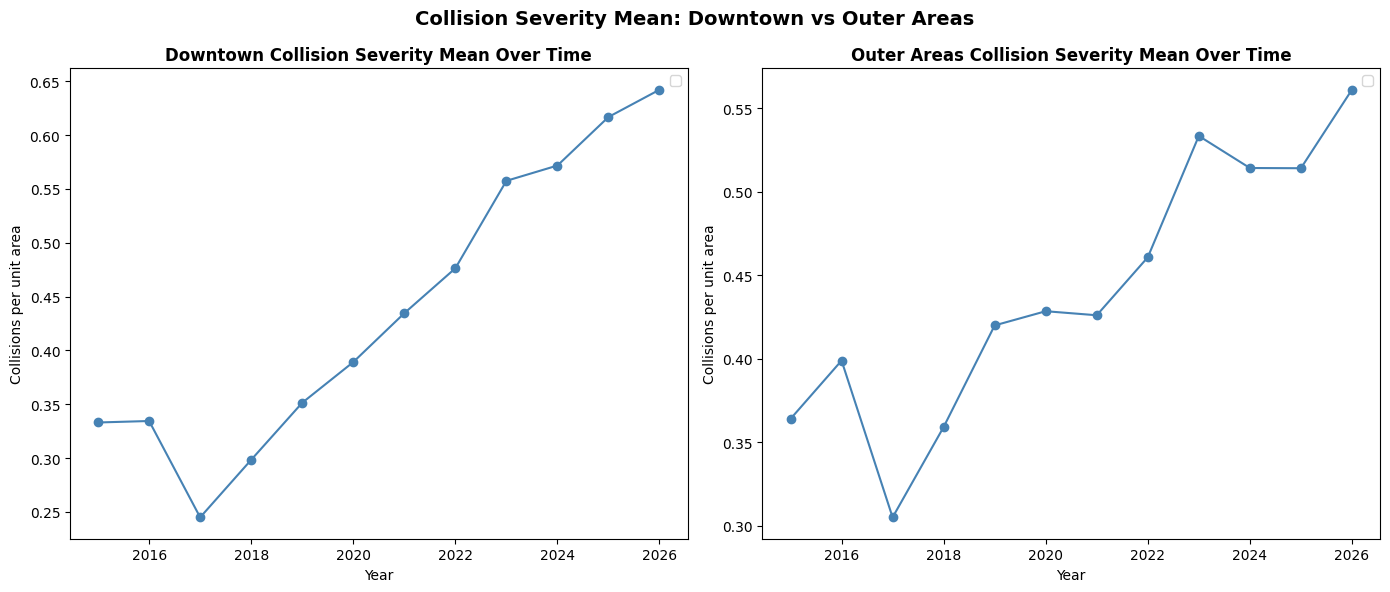

Downtown pre-2020 mean severity:  0.3132
Downtown post-2020 mean severity: 0.5111
Change: +0.1979

Outer pre-2020 mean severity:  0.3690
Outer 2020 Onwards mean severity: 0.4805
Change: +0.1114


In [7]:
# Plot severity over time side by side
dt_sev_year = df_downtown.groupby('YEAR')['SEVERITY'].mean().reset_index()
outer_sev_year = df_outer.groupby('YEAR')['SEVERITY'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (label, data) in zip(axes, [('Downtown', dt_sev_year), 
                                      ('Outer Areas', outer_sev_year)]):
    ax.plot(data['YEAR'], data['SEVERITY'], marker='o', color='steelblue')
    ax.set_title(f'{label} Collision Severity Mean Over Time', fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Collisions per unit area')
    ax.legend()

plt.suptitle('Collision Severity Mean: Downtown vs Outer Areas', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

df_downtown_pre = df_downtown[df_downtown['YEAR'] < 2020]['SEVERITY']
df_downtown_post = df_downtown[df_downtown['YEAR'] >= 2020]['SEVERITY']

print(f"Downtown pre-2020 mean severity:  {df_downtown_pre.mean():.4f}")
print(f"Downtown post-2020 mean severity: {df_downtown_post.mean():.4f}")
print(f"Change: {df_downtown_post.mean() - df_downtown_pre.mean():+.4f}")

# Same for outer
df_outer_pre = df_outer[df_outer['YEAR'] < 2020]['SEVERITY']
df_outer_post = df_outer[df_outer['YEAR'] >= 2020]['SEVERITY']

print(f"\nOuter pre-2020 mean severity:  {df_outer_pre.mean():.4f}")
print(f"Outer 2020 Onwards mean severity: {df_outer_post.mean():.4f}")
print(f"Change: {df_outer_post.mean() - df_outer_pre.mean():+.4f}")

### Comparing severity only with serious injuries and fatality injuries 
#### (`SEVERITYCODE = '2b', '3'`)

In [8]:
# Prepare columns needed by model.ipynb / tableau_prep.py
if 'TOTAL_PED' not in gdf.columns:
    gdf['TOTAL_PED'] = gdf['PEDCOUNT'] + gdf['PEDCYLCOUNT']

# Grid bins on WGS84 lat/lon (stored as strings so GeoJSON can serialize them)
gdf['lat_bin'] = pd.cut(gdf['Y'], bins=150).astype(str)
gdf['lon_bin'] = pd.cut(gdf['X'], bins=150).astype(str)

gdf[['Y', 'X', 'lat_bin', 'lon_bin', 'TOTAL_PED']].head()

,Y,X,lat_bin,lon_bin,TOTAL_PED
0,47.650458,-122.365545,"(47.65, 47.652]","(-122.366, -122.364]",0
1,47.549380,-122.334212,"(47.548, 47.55]","(-122.335, -122.333]",0
2,47.679724,-122.278475,"(47.679, 47.68]","(-122.279, -122.277]",0
3,47.599197,-122.328968,"(47.599, 47.601]","(-122.33, -122.328]",0
4,47.545014,-122.299918,"(47.543, 47.545]","(-122.301, -122.3]",0


In [10]:
gdf.to_file('../data/processed/Collision_Processed.geojson', driver='GeoJSON')